!pip install nats_bench

In [104]:
import torch
import numpy as np
import random
import os
import tarfile
from nats_bench import create
import numpy as np
import re
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader, random_split
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

from utils import set_seed, decoded_x_to_nas201_arch,pretrain_and_freeze_vae,build_accuracy_pairs
from dataset_loader import arch_to_tensor,NASDatasetFactory
from model import VAE_dist,vae_accuracy_loss,FlowNet,flow_loss
import matplotlib.pyplot as plt

# Datasets Used

In this work, two benchmark datasets are used: **NAS-Bench-201** and **NAS-Bench-301 / DARTS**.

|               | NAS-Bench-201               | NAS-Bench-301 / DARTS                                          |
| ------------- | --------------------------- | -------------------------------------------------------------- |
| Architectures | 15,625                      | ~10¹⁸ possible architectures, sampled through the search space |
| Structure     | 1 cell, 4 nodes             | 2 cells, normal and reduction, with 4 intermediate nodes each  |
| Operations    | 6                           | 8                                                              |
| Encoding      | ((6, 4, 4) = 96) dimensions | ((2, 8, 6, 6) = 504) dimensions                                |
| Accuracy      | Real lookup table           | Surrogate model, based on an ensemble predictor                |


## NAS-bench-201

In [48]:
# ── PATH CONFIG ──────────────────────────────────────────────────────────
# Questo notebook sta in progetto-deeplearning/latent_space/
# I dataset stanno in progetto-deeplearning/datasets/
BASE_DIR     = os.path.dirname(os.path.abspath('__file__'))
DATASETS_DIR = os.path.abspath(os.path.join(BASE_DIR, '../datasets'))

percorso_tar     = os.path.join(DATASETS_DIR, 'NATS-tss-v1_0-3ffb9-simple.tar')
DATASET_PATH     = os.path.join(DATASETS_DIR, 'NATS-tss-v1_0-3ffb9-simple')

# Estrazione archivio (solo la prima volta)
if not os.path.exists(DATASET_PATH):
    print('Estrazione in corso...')
    with tarfile.open(percorso_tar, 'r') as tar:
        tar.extractall(path=DATASETS_DIR)
    print('Estrazione completata!')
else:
    print('Dataset già estratto.')

# Caricamento API NATS-Bench TSS
api = create(DATASET_PATH, 'tss', fast_mode=True, verbose=False)
print(f'Architetture totali: {len(api)}')


Dataset già estratto.
Architetture totali: 15625


In [49]:
#setting seed
set_seed()
DEVICE = "cuda"

an element of the dataset: 
- DAG of the architecture where each node is a cell of operations (conv, max pooling)
- results of different datasets 

In [50]:
api.show(1)

>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> 012 epochs >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
|nor_conv_3x3~0|+|nor_conv_3x3~0|avg_pool_3x3~1|+|skip_connect~0|nor_conv_3x3~1|skip_connect~2|
datasets : ['cifar10-valid', 'cifar10', 'cifar100', 'ImageNet16-120'], extra-info : None
cifar10-valid  FLOP=113.95 M, Params=0.802 MB, latency=16.85 ms.
cifar10-valid  train : [loss = 0.382 & top1 = 86.97%], valid : [loss = 0.514 & top1 = 82.83%]
cifar10        FLOP=113.95 M, Params=0.802 MB, latency=16.85 ms.
cifar10        train : [loss = 0.243 & top1 = 91.69%], test  : [loss = 0.362 & top1 = 88.22%]
cifar100       FLOP=113.96 M, Params=0.808 MB, latency=15.36 ms.
cifar100       train : [loss = 1.271 & top1 = 63.76%], valid : [loss = 1.495 & top1 = 57.80%], test : [loss = 1.478 & top1 = 58.26%]
ImageNet16-120 FLOP= 28.50 M, Params=0.810 MB, latency=13.77 ms.
ImageNet16-120 train : [loss = 2.548 & top1 = 35.41%], valid : [loss = 2.580 & top1 = 35.43%], test : [loss = 2.611 & top1 = 33.80%]
>>>>>>>>

In [51]:
#architecture string
print(api[0])

|avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~1|+|nor_conv_1x1~0|skip_connect~1|skip_connect~2|


to see results of  a specific architecture:

In [52]:
idx = 1

# Accuracy on cifar10
info_cifar10 = api.get_more_info(idx, 'cifar10', is_random=False)
print('cifar10  test-accuracy:', info_cifar10.get('test-accuracy'))

# Accuracy on cifar100
info_cifar100 = api.get_more_info(idx, 'cifar100', is_random=False)
print('cifar100 test-accuracy:', info_cifar100.get('test-accuracy'))


cifar10  test-accuracy: 88.22
cifar100 test-accuracy: 58.25999995727539


functions for converting string into torch tensor and viceversa:

In [53]:
#converting architecture string into torch tensor
T = arch_to_tensor(arch_str=api[0])
#from torch tensor into architecture string
arch_str = decoded_x_to_nas201_arch(T)

print(T,arch_str)

[[[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 1. 1.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 0. 0.]
  [0. 0. 1. 1.]
  [0. 0. 0. 1.]
  [0. 0. 0. 0.]]

 [[0. 1. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]

 [[0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]
  [0. 0. 0. 0.]]] |avg_pool_3x3~0|+|nor_conv_1x1~0|skip_connect~1|+|nor_conv_1x1~0|skip_connect~1|skip_connect~2|


In [54]:
all_tensors = []

for i in range(len(api)):
    arch_str = api[i]
    A = arch_to_tensor(arch_str)
    all_tensors.append(A)

X = np.stack(all_tensors)  # shape: (N_architetture, 6, 4, 4)
print('X shape:', X.shape)


X shape: (15625, 6, 4, 4)


In [55]:
X = torch.tensor(X)       # shape: (N_architetture, 6, 4, 4)
X = X.view(len(X), -1)    # flatten → (N_architetture, 96)
print('X shape:', X.shape)


X shape: torch.Size([15625, 96])


### data loading 

The `NASDatasetFactory.create()` method takes as input the name of the benchmark and returns the train and test dataset and loader.

In [56]:
train_dataset,test_dataset,train_laoder,test_loader = NASDatasetFactory.create(
    benchmark_name="NAS201",
    api=api,
    dataset_name="cifar10",
    metric="test-accuracy",
    hp="12",
    flatten=True,
    normalize_y=True
)

In [57]:
print(len(train_dataset), len(test_dataset))

12500 3125


### VAE for NAS201 

Compared to the VAE used for NATS-Bench, whose input representation has 96 dimensions, the DARTS/NAS301 VAE will be deeper in order to handle a substantially larger architectural encoding.

|  | NATS-Bench VAE | 
|---|---|
| Input dimension | 96 | 
| Latent dimension | 16 | 
| Encoder | 96 → 128 → 64 → (μ, logσ²) |
| Decoder | 16 → 128 → 128 → 96 | 
| Output shape | (4, 4, 6) | 

The loss used is **vae_accuracy_loss**:
$$\mathcal{L}_{VAE}
=
\mathcal{L}_{rec}
+
\beta \, \mathcal{L}_{KL}
+
\lambda_{acc} \, \mathcal{L}_{acc}$$
where: 
- $\mathcal{L}_{rec}$ is the reconstruction loss
- $\mathcal{L}_{KL}$ is the KL divergence
- $\mathcal{L}_{acc}$ is the MSE between the predicted accuracy and the ground-truth accuracy provided by the benchmark.



In [58]:
model = VAE_dist().to(DEVICE)
loss_fn = vae_accuracy_loss

#### VAE training 

the `pretrain_and_freeze_vae()` function trains the **VAE** using the function for the loss given in input

In the following section we'll train a VAE with the loss with and without the term using the accuracy and we'll plot the principal components of the resulting latent space.
With $\lambda$ = 0:

In [ ]:
model_no_acc = pretrain_and_freeze_vae(
    model_VAE=model,
    pretrain_loader=train_laoder,
    loss_fn=vae_accuracy_loss,
    vae_epochs=200,
    beta=1.3,
    lambda_acc=0,
    DEVICE=DEVICE,
)

VAE pretrain epoch 000 | loss=0.064297 | recon=0.063789 | kl=0.000391 | acc_loss=0.705475
Early stopping: patience reached at epoch 46, best_loss=0.062939
VAE pretrained and frozen.


In [61]:
model.eval()
X_train = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))]).to(DEVICE)
y_train = torch.stack([train_dataset[i][1] for i in range(len(train_dataset))]).to(DEVICE)

with torch.no_grad():
    mu, logvar = model_no_acc.encode(X_train)
    z = mu  
z = z.cpu().numpy()  

pca = PCA(n_components=2)
z_2d_vae = pca.fit_transform(z)

with $\lambda = 1$

In [73]:
for p in model.parameters(): #unfreeze model
    p.requires_grad = True

model.train()

model_acc = pretrain_and_freeze_vae(
    model_VAE=model,
    pretrain_loader=train_laoder,
    loss_fn=vae_accuracy_loss,
    vae_epochs=50,
    beta=2,
    lambda_acc=1.0,
    DEVICE=DEVICE,
    early_stop=False,
    freeze_after=False,
    lr=1e-3
)

VAE pretrain epoch 000 | loss=0.624968 | recon=0.600767 | kl=0.005749 | acc_loss=0.012704
VAE pretrained and frozen.


In [74]:
with torch.no_grad():

    mu, logvar = model_acc.encode(X_train)

    z = mu   # embedding stabile
z = z.cpu().numpy()  # embedding del VAE

pca = PCA(n_components=2)
z_2d_vae_acc = pca.fit_transform(z)

**Plotting Latent Space:**

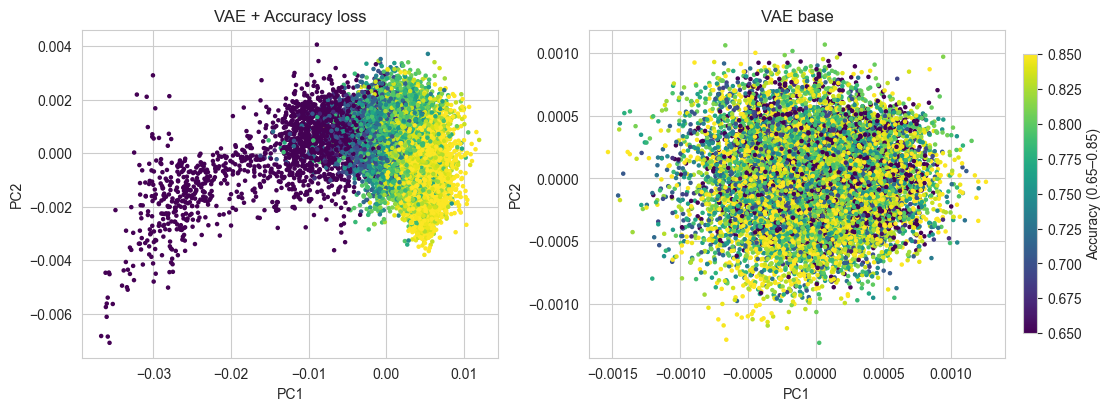

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
#y_train = y_train.detach().cpu().numpy()
sc0 = axes[0].scatter(
    z_2d_vae_acc[:,0],
    z_2d_vae_acc[:,1],
    c=y_train,
    cmap="viridis",
    s=5,
    vmin=0.65,
    vmax=0.85
)
axes[0].set_title("VAE + Accuracy loss")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

sc1 = axes[1].scatter(
    z_2d_vae[:,0],
    z_2d_vae[:,1],
    c=y_train,
    cmap="viridis",
    s=5,
    vmin=0.65,
    vmax=0.85
)
axes[1].set_title("VAE base")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
cbar = fig.colorbar(sc1, ax=axes.ravel().tolist(), shrink=0.85, pad=0.02)
cbar.set_label("Accuracy (0.65–0.85)")

plt.show()

### Flow matching 

#### **high accuracy-low accuracy** 

to test Flow Matching:
1. divido le architetture in tre classi in base all'accuracy bassa-media-alta
2. uso flow matching per muovermi nello spazio latente prima da bassa-media e poi da media-alta

In [98]:
y = y_train
idx = np.argsort(y)

n = len(y)
k = n // 2

low_idx  = idx[:k]
high_idx  = idx[k:2*k]

low_mask = np.zeros(n, dtype=bool)
high_mask = np.zeros(n, dtype=bool)

low_mask[low_idx] = True
high_mask[high_idx] = True

In [99]:
z.shape
z_low = z[low_mask]
z_high = z[high_mask]

print(z_low.shape,z_high.shape)

(6250, 16) (6250, 16)


In [101]:
flow1 = FlowNet(dim=16).to(DEVICE)
opt1 = torch.optim.Adam(flow1.parameters(), lr=1e-3)

for epoch in range(200):

    x = torch.tensor(z_low, dtype=torch.float32).to(DEVICE)
    y = torch.tensor(z_high, dtype=torch.float32).to(DEVICE)
    loss = flow_loss(flow1, x, y)

    opt1.zero_grad()
    loss.backward()
    opt1.step()

    if epoch % 20 == 0:
        print("flow1:", loss.item())

flow1: 0.0043023619800806046
flow1: 9.731106547405943e-05
flow1: 1.4414697943720967e-05
flow1: 4.734865797217935e-06
flow1: 3.6905494198435917e-06
flow1: 3.4102658901247196e-06
flow1: 3.2014459065976553e-06
flow1: 3.0250953386712354e-06
flow1: 2.8491963348642457e-06
flow1: 2.6747666197479703e-06


In [102]:
# 1. Estrai z dal test set
X_test = torch.stack([test_dataset[i][0] for i in range(len(test_dataset))])
y_test_np = np.array([float(test_dataset[i][1]) for i in range(len(test_dataset))])

# porto X_test sul device del modello
X_test = X_test.float().to(DEVICE)

model.eval()

with torch.no_grad():
    mu_test, _ = model.encode(X_test)

z_test_np = mu_test.detach().cpu().numpy()

# 2. Prendi solo i punti "low" del test
y_test_sorted = np.argsort(y_test_np)
k_test = len(y_test_np) // 2
low_idx_test = y_test_sorted[:k_test]

z_low_test = z_test_np[low_idx_test]

# 3. Applica il flow
z_low_test_tensor = torch.tensor(
    z_low_test,
    dtype=torch.float32
).to(DEVICE)

flow1.eval()

with torch.no_grad():
    v_test = flow1(z_low_test_tensor)

v_test_np = v_test.detach().cpu().numpy()

# 4. Proietta con la STESSA PCA fittata sul train
z_low_test_2d = pca.transform(z_low_test)
z_next_test_2d = pca.transform(z_low_test + v_test_np)
v_test_2d = z_next_test_2d - z_low_test_2d

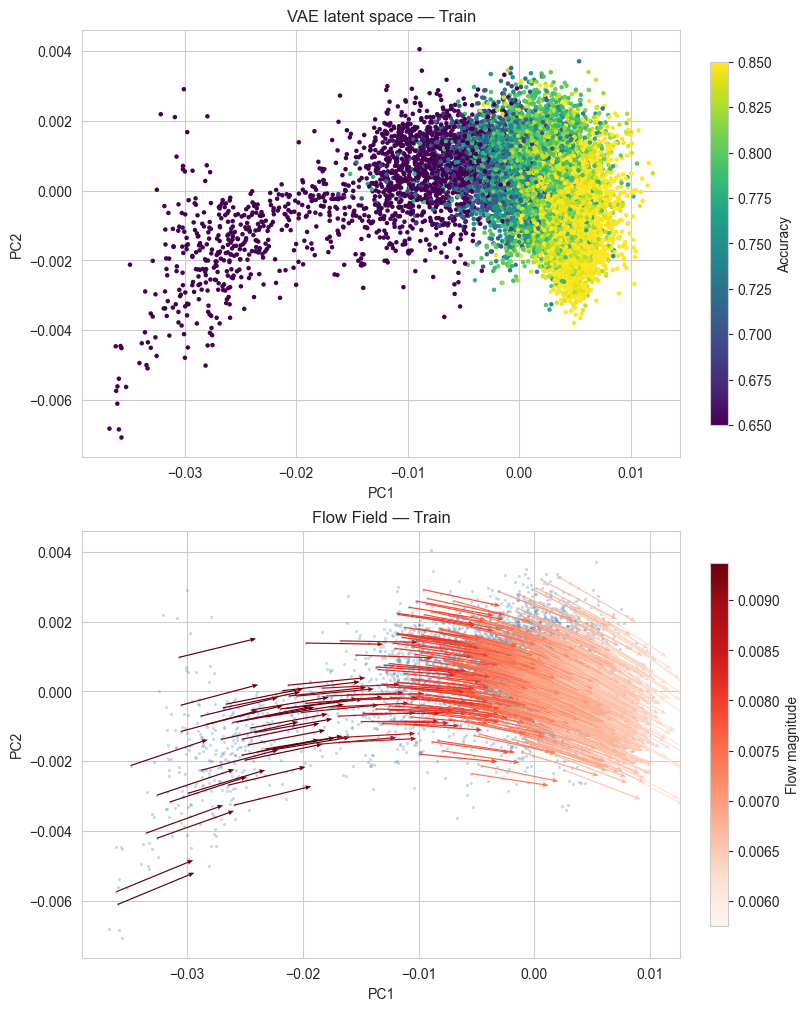

In [ ]:
# ============================================================
# 0. SETUP
# ============================================================
flow1.eval()
model.eval()

# ============================================================
# 1. LATENT SPACE (VAE) — TRAIN
# ============================================================
X_train = torch.stack([train_dataset[i][0] for i in range(len(train_dataset))])
X_train = X_train.float().to(DEVICE)

with torch.no_grad():
    mu, logvar = model.encode(X_train)
    z_all = mu

z_all_np = z_all.detach().cpu().numpy()

# y_train per matplotlib
if isinstance(y_train, torch.Tensor):
    y_train_plot = y_train.detach().cpu().numpy()
else:
    y_train_plot = np.array(y_train)

# ============================================================
# 2. FIT PCA SU TUTTO LO SPAZIO TRAIN
# ============================================================
pca = PCA(n_components=2)
pca.fit(z_all_np)

vae_2d = pca.transform(z_all_np)

# ============================================================
# 3. FLOW FIELD SU LOW SUBSET — TRAIN
# ============================================================
z_low_tensor = torch.tensor(z_low, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    v = flow1(z_low_tensor)

z_low_np = z_low_tensor.detach().cpu().numpy()
v_np = v.detach().cpu().numpy()

z_low_2d = pca.transform(z_low_np)
z_next_2d = pca.transform(z_low_np + v_np)

v_2d = z_next_2d - z_low_2d

# ============================================================
# 4. PLOT SOLO TRAIN — UNO SOTTO L'ALTRO
# ============================================================
fig, axes = plt.subplots(
    2,
    1,
    figsize=(8, 10),
    constrained_layout=True
)

# ============================================================
# (0) VAE latent space — train
# ============================================================
sc0 = axes[0].scatter(
    vae_2d[:, 0],
    vae_2d[:, 1],
    c=y_train_plot,
    cmap="viridis",
    s=5,
    vmin=0.65,
    vmax=0.85
)

axes[0].set_title("VAE latent space — Train")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

fig.colorbar(
    sc0,
    ax=axes[0],
    shrink=0.85
).set_label("Accuracy")

# ============================================================
# (1) Flow field — train
# ============================================================
v_mag = np.linalg.norm(v_2d, axis=1)
v_norm = v_2d / (v_mag[:, None] + 1e-8)
arrow_len = np.percentile(v_mag, 30)

idx = np.random.choice(
    len(z_low_2d),
    size=min(800, len(z_low_2d)),
    replace=False
)

axes[1].scatter(
    z_low_2d[:, 0],
    z_low_2d[:, 1],
    color="steelblue",
    s=5,
    alpha=0.3,
    linewidths=0,
    zorder=2
)

q = axes[1].quiver(
    z_low_2d[idx, 0],
    z_low_2d[idx, 1],
    v_norm[idx, 0] * arrow_len,
    v_norm[idx, 1] * arrow_len,
    v_mag[idx],
    cmap="Reds",
    norm=plt.Normalize(
        vmin=v_mag.min(),
        vmax=np.percentile(v_mag, 95)
    ),
    angles="xy",
    scale_units="xy",
    scale=1,
    width=0.002,
    headwidth=4,
    headlength=5,
    alpha=1,
    zorder=3
)

axes[1].set_title("Flow Field — Train")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")

fig.colorbar(
    q,
    ax=axes[1],
    shrink=0.85
).set_label("Flow magnitude")

plt.show()

## pairwise for continuous learning 

In [105]:
z_all_np = z_all.cpu().numpy()
y_train_np = y_train

pairs_x,pairs_target =build_accuracy_pairs(z_all_np, y_train_np,K=50,min_delta_acc=0.01)

In [106]:
import torch.nn as nn
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

flow = FlowNet(dim=16).to(DEVICE)

optimizer = torch.optim.Adam(
    flow.parameters(),
    lr=1e-3
)

pairs_x = pairs_x.to(DEVICE)
pairs_target = pairs_target.to(DEVICE)

epochs = 300

for epoch in range(epochs):

    pred = flow(pairs_x)

    loss = ((pred - pairs_target) ** 2).mean()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 20 == 0:

        print(
            f"Epoch {epoch} | Loss {loss.item():.6f}"
        )

Epoch 0 | Loss 0.002366
Epoch 20 | Loss 0.000021
Epoch 40 | Loss 0.000010
Epoch 60 | Loss 0.000001
Epoch 80 | Loss 0.000000
Epoch 100 | Loss 0.000000
Epoch 120 | Loss 0.000000
Epoch 140 | Loss 0.000000
Epoch 160 | Loss 0.000000
Epoch 180 | Loss 0.000000
Epoch 200 | Loss 0.000000
Epoch 220 | Loss 0.000000
Epoch 240 | Loss 0.000000
Epoch 260 | Loss 0.000000
Epoch 280 | Loss 0.000000


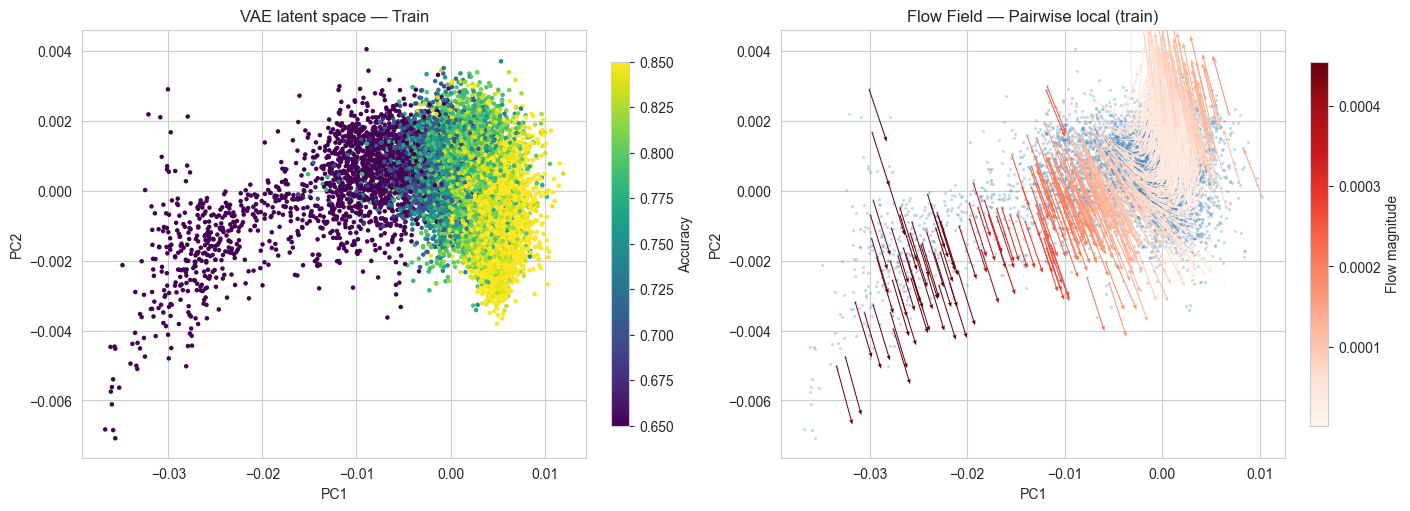

In [107]:
flow.eval()

with torch.no_grad():
    v_new = flow(torch.tensor(z_low, dtype=torch.float32).to(DEVICE))

v_new_np = v_new.cpu().numpy()

z_low_2d_new  = pca.transform(z_low)
z_next_2d_new = pca.transform(z_low + v_new_np)
v_2d_new      = z_next_2d_new - z_low_2d_new

v_mag_new  = np.linalg.norm(v_2d_new, axis=1)
v_norm_new = v_2d_new / (v_mag_new[:, None] + 1e-8)
# Con questa
x_range = z_low_2d_new[:,0].max() - z_low_2d_new[:,0].min()
arrow_len_new = x_range * 0.05  # 5% della larghezza del plot
idx_new = np.random.choice(len(z_low_2d_new), size=min(800, len(z_low_2d_new)), replace=False)

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# (0) VAE latent space
sc0 = axes[0].scatter(
    vae_2d[:,0], vae_2d[:,1],
    c=y_train, cmap="viridis",
    s=5, vmin=0.65, vmax=0.85
)
axes[0].set_title("VAE latent space — Train")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.colorbar(sc0, ax=axes[0], shrink=0.85).set_label("Accuracy")

# (1) Flow field — pairwise local
axes[1].scatter(
    z_low_2d_new[:,0], z_low_2d_new[:,1],
    color="steelblue", s=5, alpha=0.3, linewidths=0, zorder=2
)

q_new = axes[1].quiver(
    z_low_2d_new[idx_new,0], z_low_2d_new[idx_new,1],
    v_norm_new[idx_new,0] * arrow_len_new,
    v_norm_new[idx_new,1] * arrow_len_new,
    v_mag_new[idx_new], cmap="Reds",
    norm=plt.Normalize(vmin=v_mag_new.min(), vmax=np.percentile(v_mag_new, 95)),
    angles="xy", scale_units="xy", scale=1,
    width=0.002, headwidth=4, headlength=5, alpha=1, zorder=3
)
axes[1].set_title("Flow Field — Pairwise local (train)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
fig.colorbar(q_new, ax=axes[1], shrink=0.85).set_label("Flow magnitude")

plt.show()

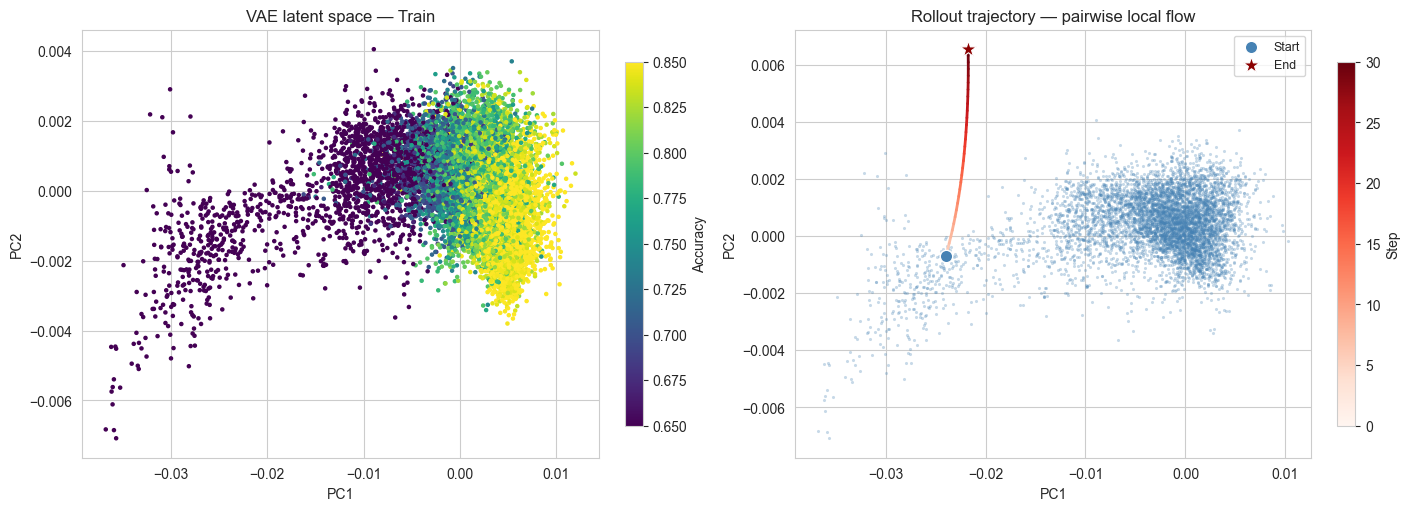

In [97]:
# ============================================================
# ROLLOUT — traiettoria multi-step
# ============================================================
start_idx = np.argmin(y_train)
z_start = z_all_np[start_idx:start_idx+1]

n_steps = 30
step_size = 1
trajectory = [z_start.copy()]

flow.eval()
z_current = z_start.copy()

with torch.no_grad():
    for _ in range(n_steps):
        z_tensor = torch.tensor(z_current, dtype=torch.float32).to(DEVICE)
        v = flow(z_tensor).cpu().numpy()
        z_current = z_current + step_size * v
        trajectory.append(z_current.copy())

trajectory = np.vstack(trajectory)
traj_2d = pca.transform(trajectory)

# ============================================================
# PLOT — stesso stile del flow field
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# (0) VAE latent space
sc0 = axes[0].scatter(
    vae_2d[:,0], vae_2d[:,1],
    c=y_train, cmap="viridis",
    s=5, vmin=0.65, vmax=0.85
)
axes[0].set_title("VAE latent space — Train")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.colorbar(sc0, ax=axes[0], shrink=0.85).set_label("Accuracy")

# (1) Traiettoria
axes[1].scatter(
    z_low_2d_new[:,0], z_low_2d_new[:,1],
    color="steelblue", s=5, alpha=0.3, linewidths=0, zorder=2
)

# Linea colorata per step con cmap="Reds"
n = len(traj_2d)
cmap_traj = plt.cm.Reds
norm_traj = plt.Normalize(0, n_steps)
for i in range(n - 1):
    t = (i + 1) / n_steps
    axes[1].plot(
        traj_2d[i:i+2, 0], traj_2d[i:i+2, 1],
        color=cmap_traj(t * 0.85 + 0.15),  # evita il bianco iniziale
        linewidth=2, solid_capstyle="round", zorder=3
    )

# Start e End
axes[1].scatter(*traj_2d[0],  s=80, color="steelblue",
    zorder=5, edgecolors="white", linewidths=1, label="Start")
axes[1].scatter(*traj_2d[-1], s=150, marker="*", color="darkred",
    zorder=5, edgecolors="white", linewidths=0.8, label="End")

sm = plt.cm.ScalarMappable(cmap=cmap_traj, norm=norm_traj)
sm.set_array([])
fig.colorbar(sm, ax=axes[1], shrink=0.85).set_label("Step")

axes[1].set_title("Rollout trajectory — pairwise local flow")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(fontsize=9, framealpha=0.8, edgecolor="#ccc")

plt.show()

# Reconstruction: 

In [ ]:
LATENT_DIM = 16
INPUT_DIM = 96

NUM_NODES = 4
NUM_OPS = 6
NUM_EDGES = NUM_NODES * NUM_NODES


class VAE_dist(nn.Module):

    def __init__(self):

        super().__init__()

        # --------------------
        # Encoder
        # --------------------
        self.fc1 = nn.Linear(INPUT_DIM, 128)
        self.fc2 = nn.Linear(128, 64)

        self.mu = nn.Linear(64, LATENT_DIM)
        self.logvar = nn.Linear(64, LATENT_DIM)

        # --------------------
        # Decoder
        # --------------------
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU()
        )

        # Logits per ogni arco del grafo e per ogni operazione
        self.edge_logits = nn.Linear(128, NUM_EDGES * NUM_OPS)

        # --------------------
        # Predictor accuracy
        # --------------------
        self.acc_predictor = nn.Sequential(
            nn.Linear(LATENT_DIM, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def encode(self, x):

        # Se x arriva come [batch, 6, 4, 4],
        # lo trasformiamo in [batch, 96]
        if x.dim() > 2:
            x = x.view(x.size(0), -1)

        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))

        mu = self.mu(h)
        logvar = self.logvar(h)

        return mu, logvar

    def reparameterize(self, mu, logvar):

        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        z = mu + eps * std

        return z

    def decode(self, z):

        h = self.decoder(z)

        logits = self.edge_logits(h)

        # logits: [batch, 4, 4, 6]
        logits = logits.view(-1, NUM_NODES, NUM_NODES, NUM_OPS)

        # probs: [batch, 4, 4, 6]
        # Per ogni arco i -> j, questa è una distribuzione sulle 6 operazioni
        probs = F.softmax(logits, dim=-1)

        return logits, probs

    def predict_acc(self, z):

        return self.acc_predictor(z)

    def forward(self, x):

        mu, logvar = self.encode(x)

        z = self.reparameterize(mu, logvar)

        recon_logits, recon_probs = self.decode(z)

        acc_pred = self.predict_acc(z)

        return recon_logits, recon_probs, mu, logvar, acc_pred

In [ ]:
import torch
import torch.nn.functional as F


def vae_accuracy_loss(
    recon_logits,
    x,
    mu,
    logvar,
    acc_pred,
    true_acc,
    beta=1.0,
    lambda_acc=1.0
):
    """
    recon_logits: [batch, 4, 4, 6]
    x:            [batch, 96]
    mu:           [batch, latent_dim]
    logvar:       [batch, latent_dim]
    acc_pred:     [batch, 1]
    true_acc:     [batch]
    """

    # x arriva appiattita: [batch, 96]
    # la riportiamo alla codifica one-hot originale: [batch, 6, 4, 4]
    x = x.reshape(x.size(0), NUM_OPS, NUM_NODES, NUM_NODES)

    # spostiamo le operazioni in ultima posizione: [batch, 4, 4, 6]
    target_onehot = x.permute(0, 2, 3, 1)

    # target discreto: [batch, 4, 4]
    target = target_onehot.argmax(dim=-1)

    # loss di ricostruzione
    recon_loss = F.cross_entropy(
        recon_logits.reshape(-1, NUM_OPS),
        target.reshape(-1).long()
    )

    # KL divergence
    kl = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    # accuracy prediction loss
    acc_loss = F.mse_loss(
        acc_pred.squeeze(-1),
        true_acc.float()
    )

    loss = recon_loss + beta * kl + lambda_acc * acc_loss

    return loss, recon_loss, kl, acc_loss

In [ ]:
epochs = 50

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

model = VAE_dist().to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)


beta= 0.01


lambda_acc = 20

model.train()

for epoch in range(epochs):

    total_loss = 0.0
    total_recon_loss = 0.0
    total_kl = 0.0
    total_acc_loss = 0.0

    num_batches = len(train_loader)

    for batch in train_loader:

        x = batch[0].to(DEVICE).float()
        y = batch[1].to(DEVICE).float()

        recon_logits, recon_probs, mu, logvar, acc_pred = model(x)

        loss, recon_loss, kl, acc_loss = vae_accuracy_loss(
            recon_logits=recon_logits,
            x=x,
            mu=mu,
            logvar=logvar,
            acc_pred=acc_pred,
            true_acc=y,
            beta=beta,
            lambda_acc=lambda_acc
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_kl += kl.item()
        total_acc_loss += acc_loss.item()

    print(
        f"Epoch {epoch+1:03d} | "
        f"Beta: {beta:.6f} | "
        f"Loss: {total_loss / num_batches:.4f} | "
        f"Recon: {total_recon_loss / num_batches:.4f} | "
        f"KL: {total_kl / num_batches:.4f} | "
        f"Acc: {total_acc_loss / num_batches:.4f}"
    )

Epoch 001 | Beta: 0.010000 | Loss: 2.4712 | Recon: 0.7642 | KL: 0.0416 | Acc: 0.0853
Epoch 002 | Beta: 0.010000 | Loss: 1.0489 | Recon: 0.6032 | KL: 0.5490 | Acc: 0.0220
Epoch 003 | Beta: 0.010000 | Loss: 0.8532 | Recon: 0.5879 | KL: 2.0822 | Acc: 0.0122
Epoch 004 | Beta: 0.010000 | Loss: 0.7814 | Recon: 0.5786 | KL: 2.0584 | Acc: 0.0091
Epoch 005 | Beta: 0.010000 | Loss: 0.7054 | Recon: 0.5797 | KL: 2.0243 | Acc: 0.0053
Epoch 006 | Beta: 0.010000 | Loss: 0.6380 | Recon: 0.5529 | KL: 2.2065 | Acc: 0.0032
Epoch 007 | Beta: 0.010000 | Loss: 0.5518 | Recon: 0.4864 | KL: 2.4947 | Acc: 0.0020
Epoch 008 | Beta: 0.010000 | Loss: 0.4630 | Recon: 0.4036 | KL: 2.8046 | Acc: 0.0016
Epoch 009 | Beta: 0.010000 | Loss: 0.3613 | Recon: 0.3021 | KL: 3.1228 | Acc: 0.0014
Epoch 010 | Beta: 0.010000 | Loss: 0.2807 | Recon: 0.2246 | KL: 3.2519 | Acc: 0.0012
Epoch 011 | Beta: 0.010000 | Loss: 0.1977 | Recon: 0.1430 | KL: 3.3655 | Acc: 0.0011
Epoch 012 | Beta: 0.010000 | Loss: 0.1289 | Recon: 0.0731 | KL: 3

In [ ]:
# predizione del decoder
pred_ops = recon_probs.argmax(dim=-1)   # [batch, 4, 4]

# originale x: [batch, 96]
x_true = x.reshape(x.size(0), NUM_OPS, NUM_NODES, NUM_NODES)

# da [batch, 6, 4, 4] a [batch, 4, 4, 6]
x_true = x_true.permute(0, 2, 3, 1)

# operazione vera per ogni arco
true_ops = x_true.argmax(dim=-1)        # [batch, 4, 4]

print("Operazioni predette:")
print(pred_ops[0])

print("\nOperazioni vere:")
print(true_ops[0])

print("\nConfronto 1=uguale, 0=diverso:")
print((pred_ops[0] == true_ops[0]).int())

Operazioni predette:
tensor([[0, 3, 4, 2],
        [0, 0, 4, 2],
        [0, 0, 0, 0],
        [0, 0, 0, 0]])

Operazioni vere:
tensor([[0, 3, 4, 2],
        [0, 0, 4, 2],
        [0, 0, 0, 0],
        [0, 0, 0, 0]])

Confronto 1=uguale, 0=diverso:
tensor([[1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1],
        [1, 1, 1, 1]], dtype=torch.int32)


In [ ]:
import numpy as np

model.eval()

z_mu_list = []
y_list = []

with torch.no_grad():

    for batch in train_loader:

        x = batch[0].to(DEVICE).float()
        y = batch[1].to(DEVICE).float()

        mu, logvar = model.encode(x)

        z_mu_list.append(mu.cpu().numpy())
        y_list.append(y.cpu().numpy())

z_mu_vae_acc = np.concatenate(z_mu_list, axis=0)
y_train_plot = np.concatenate(y_list, axis=0)

print("Latent space shape:", z_mu_vae_acc.shape)
print("y shape:", y_train_plot.shape)

Latent space shape: (12500, 16)
y shape: (12500,)


Latent space shape: (12500, 16)
y shape: (12500,)
PCA shape: (12500, 2)
Explained variance ratio: [0.21355984 0.16364361]
Explained variance total: 0.37720346


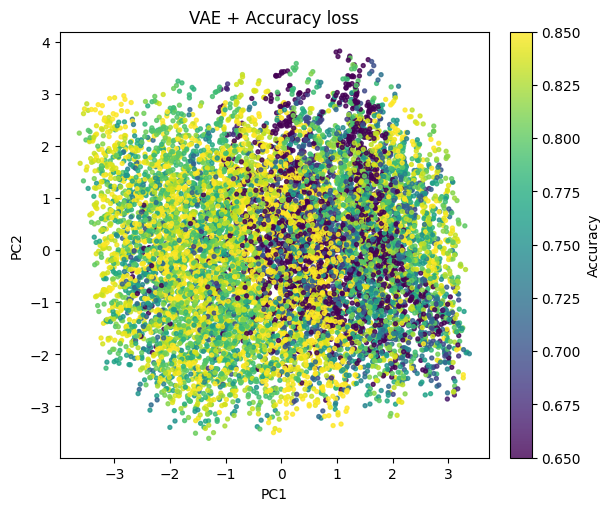

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# =========================
# 1. Estraggo i mu dal VAE
# =========================

model.eval()

z_mu_list = []
y_list = []

with torch.no_grad():

    for batch in train_loader:

        x = batch[0].to(DEVICE).float()
        y = batch[1].to(DEVICE).float()

        mu, logvar = model.encode(x)

        z_mu_list.append(mu.cpu().numpy())
        y_list.append(y.cpu().numpy())

z_mu_vae_acc = np.concatenate(z_mu_list, axis=0)
y_train_plot = np.concatenate(y_list, axis=0)

print("Latent space shape:", z_mu_vae_acc.shape)
print("y shape:", y_train_plot.shape)


# =========================
# 2. PCA da 16D a 2D
# =========================

pca = PCA(n_components=2)

z_2d_vae_acc = pca.fit_transform(z_mu_vae_acc)

print("PCA shape:", z_2d_vae_acc.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Explained variance total:", pca.explained_variance_ratio_.sum())


# =========================
# 3. Plot spazio latente
# =========================

fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)

sc = ax.scatter(
    z_2d_vae_acc[:, 0],
    z_2d_vae_acc[:, 1],
    c=y_train_plot,
    cmap="viridis",
    s=8,
    alpha=0.8,
    vmin=0.65,
    vmax=0.85
)

ax.set_title("VAE + Accuracy loss")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")

cbar = fig.colorbar(sc, ax=ax)
cbar.set_label("Accuracy")

plt.show()

- TO DO flow visualization 

In [ ]:
#pairs_x, pairs_target = pairs_generations(z_recon,y_train,K = 50)

In [ ]:
"""flow3 = FlowNet(dim=LATENT_DIM)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

optimizer = torch.optim.Adam(
    flow.parameters(),
    lr=1e-3
)

pairs_x = pairs_x.to(DEVICE)
pairs_target = pairs_target.to(DEVICE)

epochs = 300

for epoch in range(epochs):

    pred = flow(pairs_x)

    loss = ((pred - pairs_target) ** 2).mean()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch % 20 == 0:

        print(
            f"Epoch {epoch} | Loss {loss.item():.6f}"
        )"""

'flow3 = FlowNet(dim=LATENT_DIM)\n\nDEVICE = "cuda" if torch.cuda.is_available() else "cpu"\n\noptimizer = torch.optim.Adam(\n    flow.parameters(),\n    lr=1e-3\n)\n\npairs_x = pairs_x.to(DEVICE)\npairs_target = pairs_target.to(DEVICE)\n\nepochs = 300\n\nfor epoch in range(epochs):\n\n    pred = flow(pairs_x)\n\n    loss = ((pred - pairs_target) ** 2).mean()\n\n    optimizer.zero_grad()\n\n    loss.backward()\n\n    optimizer.step()\n\n    if epoch % 20 == 0:\n\n        print(\n            f"Epoch {epoch} | Loss {loss.item():.6f}"\n        )'

1. test verifichiamo se ricostruisce bene il training

In [ ]:
model.eval()

with torch.no_grad():

    x_batch, y_batch = next(iter(train_loader))
    x = x_batch.to(DEVICE).float()

    mu, logvar = model.encode(x)
    recon_logits, recon_probs = model.decode(mu)

    pred_ops = recon_probs.argmax(dim=-1)

    x_true = x.reshape(x.size(0), NUM_OPS, NUM_NODES, NUM_NODES)
    x_true = x_true.permute(0, 2, 3, 1)
    true_ops = x_true.argmax(dim=-1)

    mask = torch.zeros(NUM_NODES, NUM_NODES, dtype=torch.bool, device=DEVICE)

    for i in range(NUM_NODES):
        for j in range(NUM_NODES):
            if i < j:
                mask[i, j] = True

    recon_acc = (pred_ops[:, mask] == true_ops[:, mask]).float().mean()

    print("Reconstruction accuracy sugli archi validi:", recon_acc.item())

Reconstruction accuracy sugli archi validi: 1.0


2. test interpoliamo e vediamo se le architetture iterpolate sono buone

Latent space shape: (12500, 16)
y shape: (12500,)
PCA shape: (12500, 2)
Explained variance ratio: [0.21356001 0.16364375]
Explained variance total: 0.37720376

t = 0.00
tensor([[0, 2, 2, 4],
        [0, 0, 3, 4],
        [0, 0, 0, 0],
        [0, 0, 0, 0]])

t = 0.20
tensor([[0, 1, 2, 4],
        [0, 0, 3, 4],
        [0, 0, 0, 0],
        [0, 0, 0, 0]])

t = 0.40
tensor([[0, 1, 4, 3],
        [0, 0, 3, 3],
        [0, 0, 0, 3],
        [0, 0, 0, 0]])

t = 0.60
tensor([[0, 0, 4, 2],
        [0, 0, 4, 2],
        [0, 0, 0, 3],
        [0, 0, 0, 0]])

t = 0.80
tensor([[0, 0, 3, 2],
        [0, 0, 4, 1],
        [0, 0, 0, 3],
        [0, 0, 0, 0]])

t = 1.00
tensor([[0, 0, 3, 1],
        [0, 0, 4, 0],
        [0, 0, 0, 3],
        [0, 0, 0, 0]])


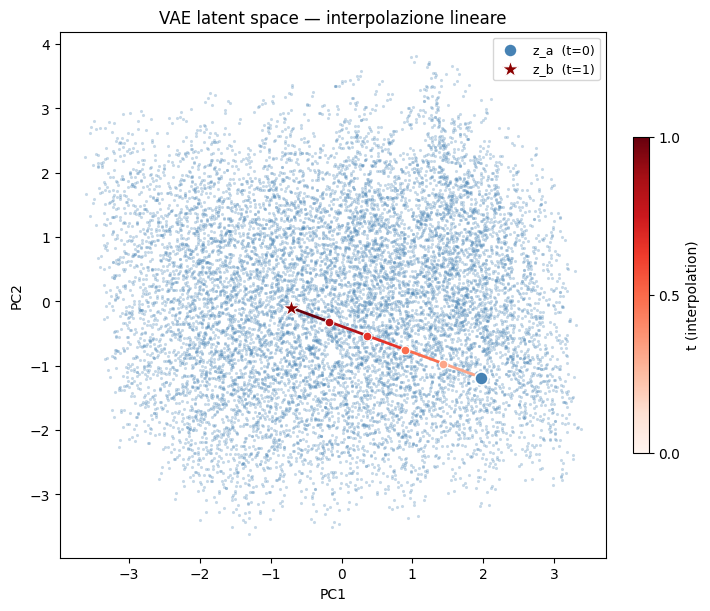

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# =========================
# 1. Estraggo i mu dal VAE
# =========================

model.eval()

z_mu_list = []
y_list = []

with torch.no_grad():

    for batch in train_loader:

        x = batch[0].to(DEVICE).float()
        y = batch[1].to(DEVICE).float()

        mu, logvar = model.encode(x)

        z_mu_list.append(mu.cpu().numpy())
        y_list.append(y.cpu().numpy())

z_mu_vae_acc = np.concatenate(z_mu_list, axis=0)
y_train_plot = np.concatenate(y_list, axis=0)

print("Latent space shape:", z_mu_vae_acc.shape)
print("y shape:", y_train_plot.shape)


# =========================
# 2. PCA da 16D a 2D
# =========================

pca = PCA(n_components=2)

z_2d_vae_acc = pca.fit_transform(z_mu_vae_acc)

print("PCA shape:", z_2d_vae_acc.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Explained variance total:", pca.explained_variance_ratio_.sum())


# =========================
# 3. Creo interpolazione tra due punti latenti
# =========================

with torch.no_grad():

    x_batch, y_batch = next(iter(train_loader))
    x = x_batch.to(DEVICE).float()

    mu, logvar = model.encode(x)

    z_a = mu[0]
    z_b = mu[1]

    ts = torch.linspace(0, 1, steps=6).to(DEVICE)

    z_interp_list = []
    ops_interp_list = []

    for t in ts:

        z_t = (1 - t) * z_a + t * z_b
        z_t_batch = z_t.unsqueeze(0)

        logits_t, probs_t = model.decode(z_t_batch)
        ops_t = probs_t.argmax(dim=-1)

        z_interp_list.append(z_t.cpu().numpy())
        ops_interp_list.append(ops_t[0].cpu())

        print(f"\nt = {t.item():.2f}")
        print(ops_t[0])

z_interp = np.stack(z_interp_list, axis=0)   # [6, 16]

# Proietto i punti interpolati nella stessa PCA
z_interp_2d = pca.transform(z_interp)        # [6, 2]


# =========================
# 4. Plot spazio latente + interpolazione
# =========================

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

# Background scatter
ax.scatter(
    z_2d_vae_acc[:, 0], z_2d_vae_acc[:, 1],
    color="steelblue", s=5, alpha=0.3, linewidths=0, zorder=1
)

# Linea interpolazione colorata per t
n = len(z_interp_2d)
cmap_traj = plt.cm.Reds
for i in range(n - 1):
    t = (i + 1) / (n - 1)
    ax.plot(
        z_interp_2d[i:i+2, 0], z_interp_2d[i:i+2, 1],
        color=cmap_traj(t * 0.85 + 0.15),
        linewidth=2, solid_capstyle="round", zorder=3
    )

# Punti intermedi (t=0.2 ... t=0.8)
for idx in range(1, n - 1):
    t = idx / (n - 1)
    ax.scatter(
        z_interp_2d[idx, 0], z_interp_2d[idx, 1],
        s=40, color=cmap_traj(t * 0.85 + 0.15),
        zorder=4, edgecolors="white", linewidths=0.8
    )
    

# Start e End
ax.scatter(*z_interp_2d[0],  s=90, color="steelblue",
    zorder=5, edgecolors="white", linewidths=1.2, label="z_a  (t=0)")
ax.scatter(*z_interp_2d[-1], s=160, marker="*", color="darkred",
    zorder=5, edgecolors="white", linewidths=0.8, label="z_b  (t=1)")

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap_traj, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6)
cbar.set_label("t (interpolation)")
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(["0.0", "0.5", "1.0"])

ax.set_title("VAE latent space — interpolazione lineare")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(fontsize=9, framealpha=0.8, edgecolor="#ccc")

plt.show()

beta=1.3 | lambda_acc=1.0 | Epoch 001 | Loss: 0.848491 | Recon: 0.772905 | KL: 0.004498 | Acc: 0.069738
beta=1.3 | lambda_acc=1.0 | Epoch 002 | Loss: 0.636268 | Recon: 0.607109 | KL: 0.000354 | Acc: 0.028699
beta=1.3 | lambda_acc=1.0 | Epoch 003 | Loss: 0.630584 | Recon: 0.606487 | KL: 0.000661 | Acc: 0.023238
beta=1.3 | lambda_acc=1.0 | Epoch 004 | Loss: 0.628001 | Recon: 0.606549 | KL: 0.000539 | Acc: 0.020752
beta=1.3 | lambda_acc=1.0 | Epoch 005 | Loss: 0.626754 | Recon: 0.606370 | KL: 0.000409 | Acc: 0.019853
beta=1.3 | lambda_acc=1.0 | Epoch 006 | Loss: 0.625679 | Recon: 0.605964 | KL: 0.000310 | Acc: 0.019311
beta=1.3 | lambda_acc=1.0 | Epoch 007 | Loss: 0.625586 | Recon: 0.605995 | KL: 0.000242 | Acc: 0.019276
beta=1.3 | lambda_acc=1.0 | Epoch 008 | Loss: 0.625264 | Recon: 0.605920 | KL: 0.000224 | Acc: 0.019053
beta=1.3 | lambda_acc=1.0 | Epoch 009 | Loss: 0.624876 | Recon: 0.605668 | KL: 0.000200 | Acc: 0.018948
beta=1.3 | lambda_acc=1.0 | Epoch 010 | Loss: 0.624900 | Recon: 

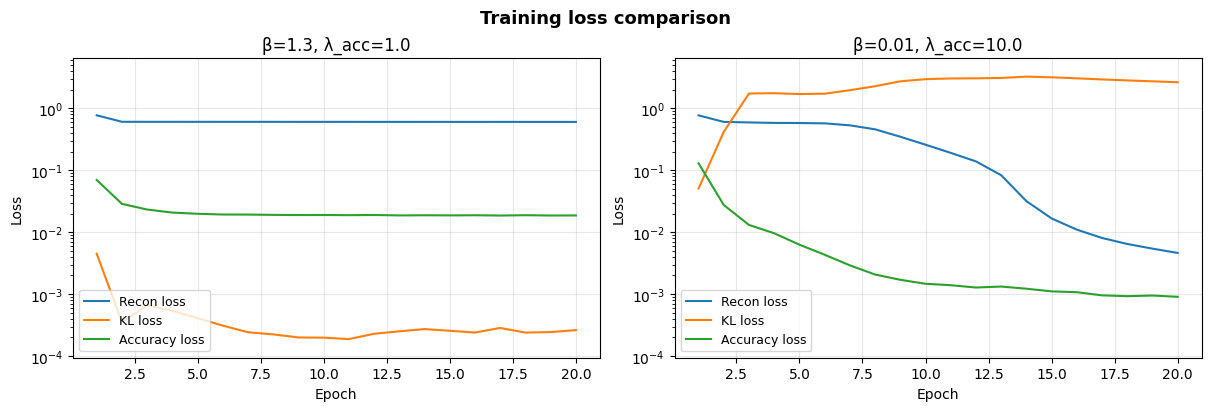

In [ ]:

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# ============================================================
# 1. FUNZIONE DI TRAINING
# ============================================================

def train_vae_model(beta, lambda_acc, epochs=50, lr=1e-3):

    model = VAE_dist().to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    history = {
        "total": [],
        "recon": [],
        "kl": [],
        "acc": []
    }

    model.train()

    for epoch in range(epochs):

        total_loss = 0.0
        total_recon_loss = 0.0
        total_kl = 0.0
        total_acc_loss = 0.0

        num_batches = len(train_loader)

        for batch in train_loader:

            x = batch[0].to(DEVICE).float()
            y = batch[1].to(DEVICE).float()

            recon_logits, recon_probs, mu, logvar, acc_pred = model(x)

            loss, recon_loss, kl, acc_loss = vae_accuracy_loss(
                recon_logits=recon_logits,
                x=x,
                mu=mu,
                logvar=logvar,
                acc_pred=acc_pred,
                true_acc=y,
                beta=beta,
                lambda_acc=lambda_acc
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon_loss += recon_loss.item()
            total_kl += kl.item()
            total_acc_loss += acc_loss.item()

        avg_total = total_loss / num_batches
        avg_recon = total_recon_loss / num_batches
        avg_kl = total_kl / num_batches
        avg_acc = total_acc_loss / num_batches

        history["total"].append(avg_total)
        history["recon"].append(avg_recon)
        history["kl"].append(avg_kl)
        history["acc"].append(avg_acc)

        print(
            f"beta={beta} | lambda_acc={lambda_acc} | "
            f"Epoch {epoch+1:03d} | "
            f"Loss: {avg_total:.6f} | "
            f"Recon: {avg_recon:.6f} | "
            f"KL: {avg_kl:.6f} | "
            f"Acc: {avg_acc:.6f}"
        )

    return model, history


# ============================================================
# 2. FUNZIONE PER ESTRARRE LATENT SPACE E PCA
# ============================================================

def extract_latent_space_with_pca(model):

    model.eval()

    z_mu_list = []
    y_list = []

    with torch.no_grad():

        for batch in train_loader:

            x = batch[0].to(DEVICE).float()
            y = batch[1].to(DEVICE).float()

            mu, logvar = model.encode(x)

            z_mu_list.append(mu.cpu().numpy())
            y_list.append(y.cpu().numpy())

    z_mu = np.concatenate(z_mu_list, axis=0)
    y_plot = np.concatenate(y_list, axis=0)

    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z_mu)

    print("Latent shape:", z_mu.shape)
    print("PCA shape:", z_2d.shape)
    print("Explained variance ratio:", pca.explained_variance_ratio_)
    print("Explained variance total:", pca.explained_variance_ratio_.sum())

    return z_mu, z_2d, y_plot, pca


# ============================================================
# 3. PARAMETRI DEI DUE ESPERIMENTI
# ============================================================

epochs = 20

beta_1 = 1.3
lambda_acc_1 = 1.0

beta_2 = 0.01
lambda_acc_2 = 10.0


# ============================================================
# 4. TRAINING DEI DUE MODELLI
# ============================================================

model_1, history_1 = train_vae_model(
    beta=beta_1,
    lambda_acc=lambda_acc_1,
    epochs=epochs,
    lr=1e-3
)

model_2, history_2 = train_vae_model(
    beta=beta_2,
    lambda_acc=lambda_acc_2,
    epochs=epochs,
    lr=1e-3
)


# ============================================================
# 5. ESTRAZIONE LATENT SPACE + PCA CONDIVISA
# ============================================================

z_mu_1, z_2d_1, y_plot_1, _ = extract_latent_space_with_pca(model_1)
z_mu_2, z_2d_2, y_plot_2, _ = extract_latent_space_with_pca(model_2)

# PCA fittata su entrambi i modelli insieme
pca_shared = PCA(n_components=2)
pca_shared.fit(np.concatenate([z_mu_1, z_mu_2], axis=0))
z_2d_1 = pca_shared.transform(z_mu_1)
z_2d_2 = pca_shared.transform(z_mu_2)

# Limiti comuni per gli assi
x_min = min(z_2d_1[:,0].min(), z_2d_2[:,0].min())
x_max = max(z_2d_1[:,0].max(), z_2d_2[:,0].max())
y_min = min(z_2d_1[:,1].min(), z_2d_2[:,1].min())
y_max = max(z_2d_1[:,1].max(), z_2d_2[:,1].max())
pad = 0.05
xlim = (x_min - pad * abs(x_min), x_max + pad * abs(x_max))
ylim = (y_min - pad * abs(y_min), y_max + pad * abs(y_max))

# ============================================================
# 6. GRIGLIA 2x2
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

epochs_range = np.arange(1, epochs + 1)

loss_min = min(
    min(history_1["recon"]), min(history_1["kl"]), min(history_1["acc"]),
    min(history_2["recon"]), min(history_2["kl"]), min(history_2["acc"])
)
loss_max = max(
    max(history_1["recon"]), max(history_1["kl"]), max(history_1["acc"]),
    max(history_2["recon"]), max(history_2["kl"]), max(history_2["acc"])
)

for ax, history, beta, lambda_acc in zip(
    axes,
    [history_1, history_2],
    [beta_1, beta_2],
    [lambda_acc_1, lambda_acc_2]
):
    ax.plot(epochs_range, history["recon"], label="Recon loss")
    ax.plot(epochs_range, history["kl"],    label="KL loss")
    ax.plot(epochs_range, history["acc"],   label="Accuracy loss")
    ax.set_title(f"β={beta}, λ_acc={lambda_acc}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_yscale("log")
    ax.set_ylim(loss_min * 0.5, loss_max * 2)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Training loss comparison", fontsize=13, fontweight="bold")
plt.show()